In [30]:
# analyse trajectory and planetary encounters of Comet C/2025 N1 (ATLAS)
import re
import numpy as np
import matplotlib.pyplot as plt

# read file
with open("comet_results.txt", "r", encoding="utf-8") as f:
    text = f.read()

# only take the data between $$SOE and $$EOE 
start = text.index("$$SOE") + len("$$SOE")
end = text.index("$$EOE") if "$$EOE" in text else len(text)
data_block = text[start:end].strip()

lines = [line.strip() for line in data_block.splitlines() if line.strip()]

times = []
x_list, y_list, z_list = [], [], []
vx_list, vy_list, vz_list = [], [], []

# parse the Horizons vector table
i = 0
while i < len(lines) - 2:
    time_line = lines[i] # time
    pos_line = lines[i + 1] # X Y Z
    vel_line = lines[i + 2] # VX VY VZ

    if "X =" not in pos_line:
        i += 1
        continue

    times.append(time_line)

    x = float(re.search(r"X\s*=\s*([-\d.E+]+)", pos_line).group(1))
    y = float(re.search(r"Y\s*=\s*([-\d.E+]+)", pos_line).group(1))
    z = float(re.search(r"Z\s*=\s*([-\d.E+]+)", pos_line).group(1))

    vx = float(re.search(r"VX\s*=\s*([-\d.E+]+)", vel_line).group(1))
    vy = float(re.search(r"VY\s*=\s*([-\d.E+]+)", vel_line).group(1))
    vz = float(re.search(r"VZ\s*=\s*([-\d.E+]+)", vel_line).group(1))

    x_list.append(x)
    y_list.append(y)
    z_list.append(z)
    vx_list.append(vx)
    vy_list.append(vy)
    vz_list.append(vz)

    i += 3

# convert to numpy array
x = np.array(x_list)
y = np.array(y_list)
z = np.array(z_list)
vx = np.array(vx_list)
vy = np.array(vy_list)
vz = np.array(vz_list)

print("Number of data points:", len(x))
print("First X,Y,Z:", x[0], y[0], z[0])

Number of data points: 220
First X,Y,Z: 1156437444.479337 -3241534628.849548 158130543.4196271


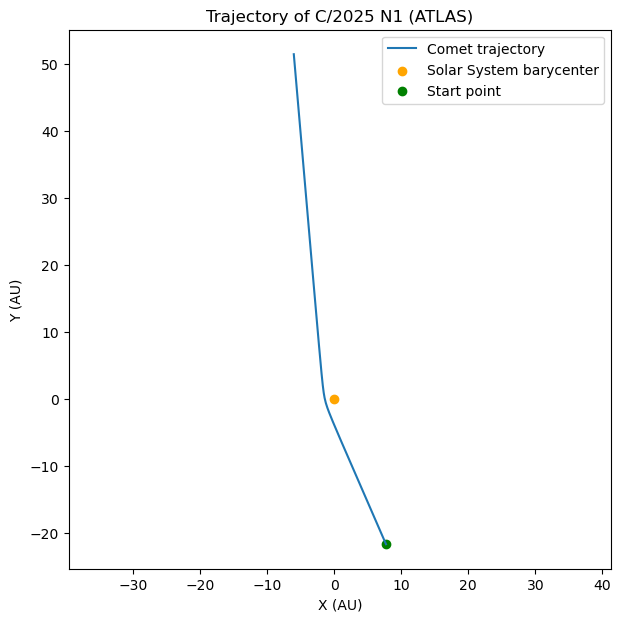

In [25]:
AU = 1.495978707e8 # convert km -> AU

x_au = x / AU
y_au = y / AU

plt.figure(figsize=(7,7)) # plot comet trajectory

plt.plot(x_au, y_au, label="Comet trajectory")
plt.scatter(0,0,color="orange", label="Solar System barycenter")

plt.scatter(x_au[0], y_au[0], color="green", label="Start point")

plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.title("Trajectory of C/2025 N1 (ATLAS)")

plt.legend()

plt.axis("equal")
plt.show()

In [26]:
# compute closest approach (perihelion) of comet to the Sun
r = np.sqrt(x**2 + y**2 + z**2) / AU

min_r = np.min(r)
min_index = np.argmin(r)

print("Minimum distance to Sun (AU):", min_r)
print("Time of closest approach:", times[min_index])

Minimum distance to Sun (AU): 1.3639862040741584
Time of closest approach: 2460980.500000000 = A.D. 2025-Nov-01 00:00:00.0000 TDB


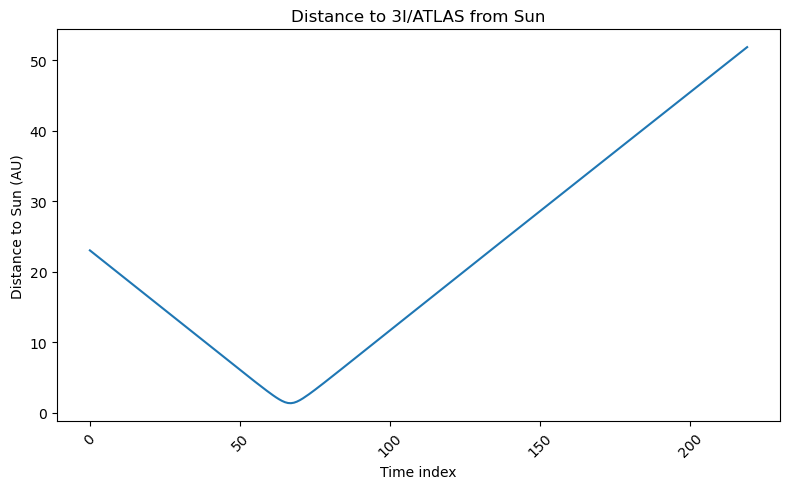

In [27]:
# visualise comet-Sun distance over time to identify perihelion
plt.figure(figsize=(8,5))
plt.plot(r)
plt.xlabel("Time index")
plt.ylabel("Distance to Sun (AU)")
plt.title("Distance to 3I/ATLAS from Sun")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# parse NASA Horizons vector table to extract time and 3D position data
def parse_horizons_vectors_simple(filename):
    with open(filename, "r", encoding="utf-8") as f:
        text = f.read()

    start = text.index("$$SOE") + len("$$SOE")
    end = text.index("$$EOE") if "$$EOE" in text else len(text)
    data_block = text[start:end].strip()

    lines = [line.strip() for line in data_block.splitlines() if line.strip()]

    times = []
    x_list, y_list, z_list = [], [], []

    i = 0
    while i < len(lines) - 2:
        time_line = lines[i]
        pos_line = lines[i + 1]

        if "X =" not in pos_line:
            i += 1
            continue

        times.append(time_line)

        x = float(re.search(r"X\s*=\s*([-\d.E+]+)", pos_line).group(1))
        y = float(re.search(r"Y\s*=\s*([-\d.E+]+)", pos_line).group(1))
        z = float(re.search(r"Z\s*=\s*([-\d.E+]+)", pos_line).group(1))

        x_list.append(x)
        y_list.append(y)
        z_list.append(z)

        i += 4

    return np.array(times), np.array(x_list), np.array(y_list), np.array(z_list)

In [31]:
earth_times, xE, yE, zE = parse_horizons_vectors_simple("earth_results.txt")
jupiter_times, xJ, yJ, zJ = parse_horizons_vectors_simple("jupiter_results.txt")

print("Comet points:", len(x))
print("Earth points:", len(xE))
print("Jupiter points:", len(xJ))

# compute 3D distance between comet and planets (in AU)
r_earth = np.sqrt((x - xE)**2 + (y - yE)**2 + (z - zE)**2) / AU
r_jupiter = np.sqrt((x - xJ)**2 + (y - yJ)**2 + (z - zJ)**2) / AU

min_r_earth = np.min(r_earth)
min_index_earth = np.argmin(r_earth)

min_r_jupiter = np.min(r_jupiter)
min_index_jupiter = np.argmin(r_jupiter)

print("Minimum distance to Earth (AU):", min_r_earth)
print("Time of closest approach to Earth:", times[min_index_earth])

print("Minimum distance to Jupiter (AU):", min_r_jupiter)
print("Time of closest approach to Jupiter:", times[min_index_jupiter])

Comet points: 220
Earth points: 220
Jupiter points: 220
Minimum distance to Earth (AU): 1.7990685175683185
Time of closest approach to Earth: 2461030.500000000 = A.D. 2025-Dec-21 00:00:00.0000 TDB
Minimum distance to Jupiter (AU): 0.39692349623532236
Time of closest approach to Jupiter: 2461120.500000000 = A.D. 2026-Mar-21 00:00:00.0000 TDB


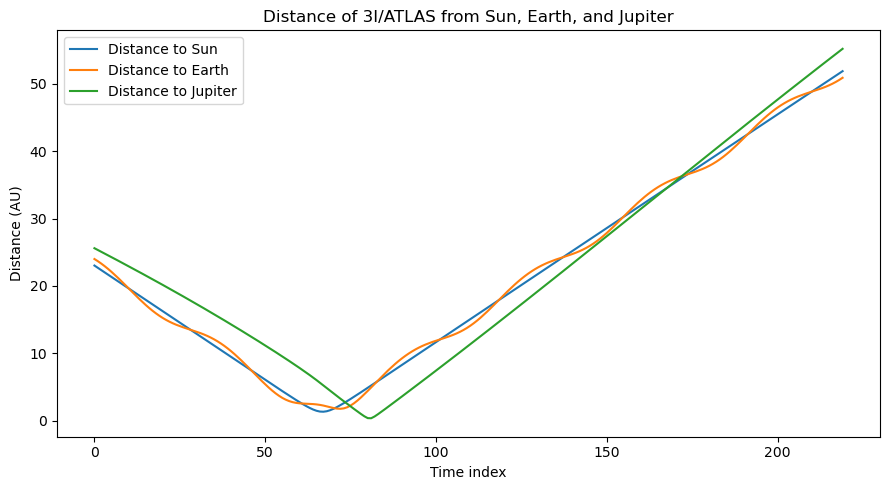

In [22]:
# compare comet distances to Sun, Earth, and Jupiter to identify closest encounters
plt.figure(figsize=(9,5))
plt.plot(r, label="Distance to Sun")
plt.plot(r_earth, label="Distance to Earth")
plt.plot(r_jupiter, label="Distance to Jupiter")

plt.xlabel("Time index")
plt.ylabel("Distance (AU)")
plt.title("Distance of 3I/ATLAS from Sun, Earth, and Jupiter")
plt.legend()
plt.tight_layout()
plt.show()